# 1. Importing the dependencies

---

In [25]:
!pip install transformers datasets --quiet

In [26]:
import numpy as np
import pandas as pd
from datasets import Dataset
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification
import tensorflow as tf
from sklearn.model_selection import train_test_split

# 2. Data Loading and Understanding

---


In [27]:
# Load CSV with proper encoding and columns
columns = ['target', 'id', 'date', 'flag', 'user', 'text']
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Sentiment_Analysis_on_Social_media/training.1600000.processed.noemoticon.csv',
                 encoding='ISO-8859-1', names=columns, header=None)


In [28]:
df.shape

(1600000, 6)

In [29]:
df.head()

,target,id,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 6 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   target  1600000 non-null  int64 
 1   id      1600000 non-null  int64 
 2   date    1600000 non-null  object
 3   flag    1600000 non-null  object
 4   user    1600000 non-null  object
 5   text    1600000 non-null  object
dtypes: int64(2), object(4)
memory usage: 73.2+ MB


In [31]:
# Check for missing values
df.isnull().sum().sum()

np.int64(0)

In [32]:
# Add a new column for text length
df['text_length'] = df['text'].apply(len)

# Basic stats
df['text_length'].describe()

,text_length
count,1.600000e+06
mean,7.409011e+01
std,3.644114e+01
min,6.000000e+00
25%,4.400000e+01
50%,6.900000e+01
75%,1.040000e+02
max,3.740000e+02


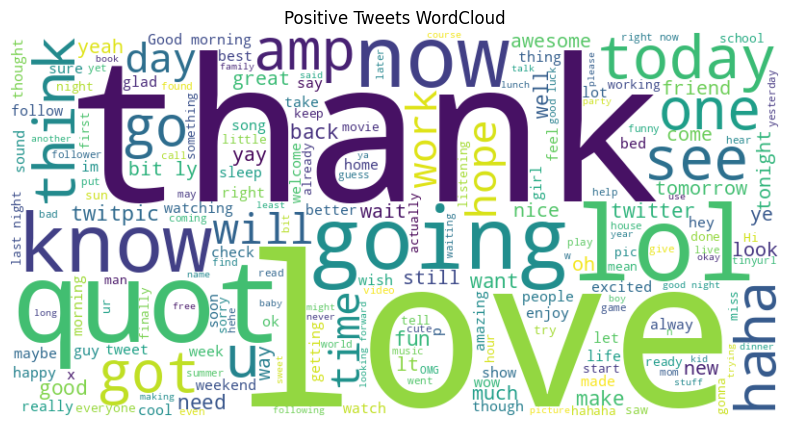

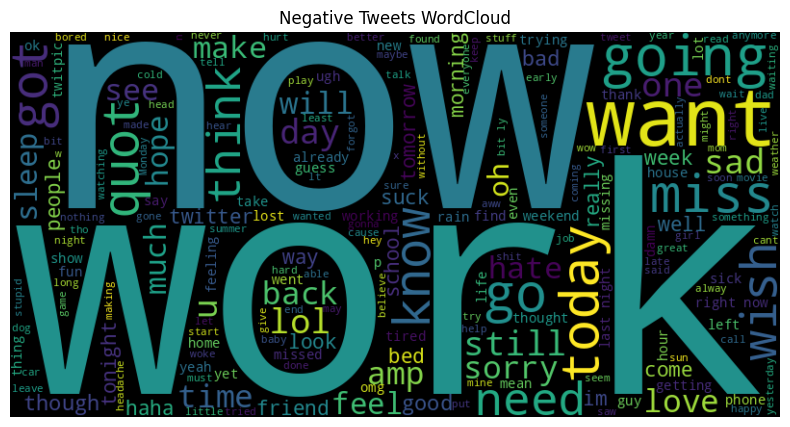

In [33]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all text for positive and negative
positive_text = " ".join(df[df['target'] == 4]['text'].tolist())
negative_text = " ".join(df[df['target'] == 0]['text'].tolist())

# WordCloud for positive tweets
wordcloud_pos = WordCloud(width=800, height=400, background_color='white').generate(positive_text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title("Positive Tweets WordCloud")
plt.show()

# WordCloud for negative tweets
wordcloud_neg = WordCloud(width=800, height=400, background_color='black').generate(negative_text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title("Negative Tweets WordCloud")
plt.show()

In [11]:
# number of unique values in each column
for col in df.columns:
    print(f"\nColumn: {col}")
    print(f"Number of unique values: {df[col].nunique()}")
    print(f"Unique values (sample): {df[col].unique()[:5]}")  # Show only first 5 unique values


Column: target
Number of unique values: 2
Unique values (sample): [0 4]

Column: id
Number of unique values: 1598315
Unique values (sample): [1467810369 1467810672 1467810917 1467811184 1467811193]

Column: date
Number of unique values: 774363
Unique values (sample): ['Mon Apr 06 22:19:45 PDT 2009' 'Mon Apr 06 22:19:49 PDT 2009'
 'Mon Apr 06 22:19:53 PDT 2009' 'Mon Apr 06 22:19:57 PDT 2009'
 'Mon Apr 06 22:20:00 PDT 2009']

Column: flag
Number of unique values: 1
Unique values (sample): ['NO_QUERY']

Column: user
Number of unique values: 659775
Unique values (sample): ['_TheSpecialOne_' 'scotthamilton' 'mattycus' 'ElleCTF' 'Karoli']

Column: text
Number of unique values: 1581466
Unique values (sample): ["@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D"
 "is upset that he can't update his Facebook by texting it... and might cry as a result  School today also. Blah!"
 '@Kenichan I dived many times for the ball. Managed 

# **Data Preprocessing**

In [34]:
# Filter only target labels 0, 4 and convert to binary
df = df[df['target'].isin([0, 4])]
df['target'] = df['target'].apply(lambda x: 0 if x == 0 else 1)

# Use only half of the data
df = df.iloc[:800000]

In [35]:
# Train-test split
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)


In [36]:
# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

# Tokenization function
def tokenize_fn(batch):
    return tokenizer(batch['text'], padding="max_length", truncation=True, max_length=128)


In [37]:
# Convert to Hugging Face Datasets
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)

# Tokenize and remove unnecessary columns
train_dataset = train_dataset.map(tokenize_fn, batched=True, remove_columns=['id', 'date', 'flag', 'user', 'text', '__index_level_0__'])
val_dataset = val_dataset.map(tokenize_fn, batched=True, remove_columns=['id', 'date', 'flag', 'user', 'text', '__index_level_0__'])


Map:   0%|          | 0/640000 [00:00<?, ? examples/s]

Map:   0%|          | 0/160000 [00:00<?, ? examples/s]

In [38]:
train_dataset.set_format(type='numpy', columns=['input_ids', 'attention_mask', 'target'])
val_dataset.set_format(type='numpy', columns=['input_ids', 'attention_mask', 'target'])


In [41]:
# Convert to pandas first to avoid Arrow-backed arrays issue
train_df_fixed = train_dataset.to_pandas()
val_df_fixed = val_dataset.to_pandas()

# Now convert to TensorFlow datasets safely
train_tf_dataset = tf.data.Dataset.from_tensor_slices((
    {
        "input_ids": np.array(train_df_fixed['input_ids'].tolist()),
        "attention_mask": np.array(train_df_fixed['attention_mask'].tolist()),
    },
    np.array(train_df_fixed['target'].tolist())
)).shuffle(1000).batch(32)

val_tf_dataset = tf.data.Dataset.from_tensor_slices((
    {
        "input_ids": np.array(val_df_fixed['input_ids'].tolist()),
        "attention_mask": np.array(val_df_fixed['attention_mask'].tolist()),
    },
    np.array(val_df_fixed['target'].tolist())
)).batch(32)

# **Fine Tuning BERT model**

In [42]:
# Load pre-trained DistilBERT for binary classification
model = TFAutoModelForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_projector.bias', 'vocab_layer_norm.weight', 'vocab_layer_norm.bias', 'vocab_transform.weight', 'vocab_transform.bias']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'classifier.bias']
You should 

In [43]:
# Compile model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=3e-5),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])


In [45]:
# Train for 1 epoch
history = model.fit(train_tf_dataset, validation_data=val_tf_dataset, epochs=1)

20000/20000 [==============================] - 8275s 414ms/step - loss: 1.7544e-08 - accuracy: 1.0000 - val_loss: 0.0000e+00 - val_accuracy: 1.0000


# **Evaluating the model**

In [46]:
# Evaluate model on validation set
model.evaluate(val_tf_dataset)


5000/5000 [==============================] - 688s 138ms/step - loss: 0.0000e+00 - accuracy: 1.0000


[0.0, 1.0]

# **Saving the model**

In [47]:
model.save_pretrained("/content/drive/MyDrive/sentiment_model")
tokenizer.save_pretrained("/content/drive/MyDrive/sentiment_model")

('/content/drive/MyDrive/sentiment_model/tokenizer_config.json',
 '/content/drive/MyDrive/sentiment_model/special_tokens_map.json',
 '/content/drive/MyDrive/sentiment_model/vocab.txt',
 '/content/drive/MyDrive/sentiment_model/added_tokens.json',
 '/content/drive/MyDrive/sentiment_model/tokenizer.json')

In [48]:
print("Completed")

Completed
